In [1]:
%load_ext autoreload
%autoreload 2
from matplotlib import pyplot as plt
import numpy as np
import lmfit
import xarray as xr
import dask.array as da
import os
import timeit
from xcube.core.store import new_data_store

from bio_optics.inversion import dask_engine
from bio_optics.reflectance import bi #albert_mobley
# from bio_optics.surface import reflectance as surface_reflectance
from bio_optics.helper import resampling, utils
from bio_optics.atmosphere import downwelling_irradiance
from bio_optics.water import absorption, backscattering, fluorescence, attenuation

In [2]:
%reload_ext autoreload

In [3]:
import bio_optics
bio_optics.water.__file__

'D:\\Documents\\projects\\bio_optics_dev\\bio_optics\\bio_optics\\water\\__init__.py'

In [4]:
def find_closest(arr: np.array, val: int):  
  """ 
  Find the closest value to a number in an array.
  
  :param arr:  an array or list of numbers
  :param val:  the number  
  :return:     the closest value and its index in arr
  """
  arr = np.asarray(arr)
  idx = (np.abs(arr - val)).argmin()
  
  return arr[idx], idx

# Read EnMAP

In [5]:
root = 'D:\Documents\projects\EnsAD\EnMAP\L2A_Water\\v010502\Waddensea\zarr\\'
zarrList = os.listdir(root)
dateList = ['20240530', '20240626', '20240727', '20240819', '20240831', '20241112']
## goodExamples = {'20240626': ['_005_', '_006_', '_007_'], '20240727': ['_001_', '_002_', '_003_'], 
##    '20240819':['_004_', '_005_', '_007_' ], '20240831':['_001_', '_002_'], '20241112'}
zarrList = [z for z in zarrList if dateList[4] in z]
print(len(zarrList))
zarrFname = zarrList[1]
print(zarrFname)
local = new_data_store("file", root=root)
dr = local.open_data(zarrFname)
wl = dr.band.values
ind665_, ind665 = find_closest(wl, 665)
ind560_, ind560 = find_closest(wl, 560)
ind440_, ind440 = find_closest(wl, 440)

flags2D = dr.quality_classes.values[:,:]

# wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865]) # selection
ID = wl < 850.
wavelengths = wl[ID]
band_vars = []
for w in wavelengths:
    ind_, ind = find_closest(wl, w)
    band_vars.append(ind)

# print(band_vars)

# ref_band          = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(dr.band_data.isel(band=0).dims)
spatial_coords    = {d: dr[d].values for d in spatial_dim_names if d in dr.coords}

Rrs_image = np.stack(
    [dr.band_data.isel(band=v).values for v in band_vars], axis=-1
) #/ np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_pixels = n_rows * n_cols
print(f'Rrs_image: {Rrs_image.shape}  ({n_pixels} pixels, {n_obs} bands)')

2
enmapZarr_ENMAP01-____L2A-DT0000090299_20240831T112133Z_002_V010502_20250116T085503Z.zarr
Rrs_image: (930, 1648, 73)  (1532640 pixels, 73 bands)


47 29 4
NDWI [561.112 871.683]


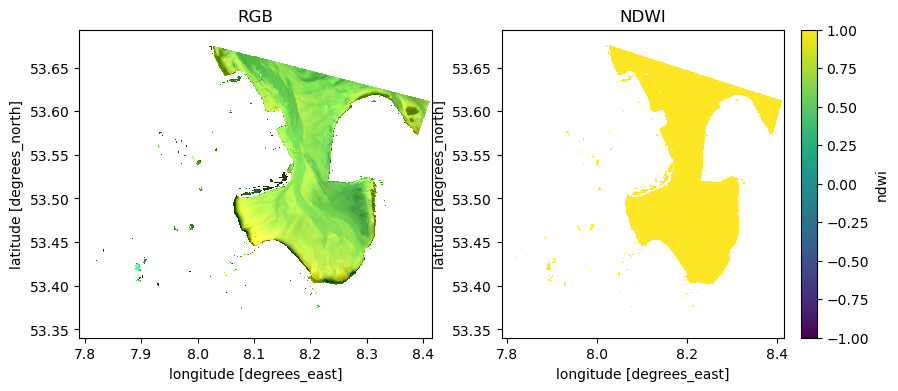

In [6]:
# dr.band_data.isel(band=10).plot()
print(ind665, ind560, ind440)
fig, ax = plt.subplots(ncols=2, figsize=(10,4))
dr.band_data.isel(band = [ind665, ind560, ind440]).plot.imshow(ax=ax[0], robust=True)
ax[0].set_title('RGB')

Rrs_ndwi = dr.band_data.isel(band=[29,75]).values #dr.band_data.isel(band=[29, 75]).values
print('NDWI', wl[[29, 75]])
ndwi = (Rrs_ndwi[0,:,:] - Rrs_ndwi[1,:,:]) / (Rrs_ndwi[0, :,:] + Rrs_ndwi[1, :,:])
dr = dr.assign(ndwi=(['y', 'x'], ndwi))
dr.ndwi.plot(ax=ax[1], vmin=-1, vmax=1)
ax[1].set_title('NDWI')
plt.show()

In [7]:
## setup mini cube for testing
cube1 = da.stack([dr.band_data.isel(band=v).sel(y=slice(53.65, 53.635), x=slice(8.1, 8.12)).values for v in band_vars])
cube1 = cube1.rechunk(chunks=(cube1.shape[0],32,32))
cube1

dask.array<rechunk-merge, shape=(73, 39, 52), dtype=float32, chunksize=(73, 32, 32), chunktype=numpy.ndarray>

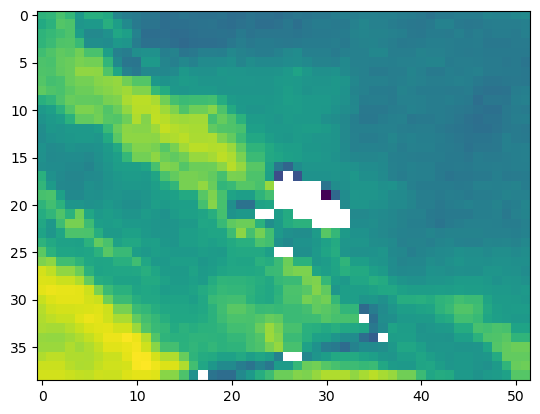

In [8]:
#ind665, ind560, ind440
plt.imshow(cube1[ind665,:,:])

In [5]:
# prep cubes and make sure they both have the same chunking
# cube1 = da.stack([dataset.isel(time=1)[var].data for var in dataset.isel(time=1).data_vars][1:]) / np.pi
# cube1 = cube1.rechunk(chunks=(cube1.shape[0],32,32))
cube1 = da.stack([dr.band_data.isel(band=v).values for v in band_vars])
cube1 = cube1.rechunk(chunks=(cube1.shape[0],32,32))
cube1

dask.array<rechunk-merge, shape=(73, 930, 1648), dtype=float32, chunksize=(73, 32, 32), chunktype=numpy.ndarray>

## Resample LUTs

In [9]:
regionName='NorthSea'
sensor = 'EnMAP'
versionAC = 'EnMAPWaterv1.5.2'
dataType = 'EnMAPTile' # 'Sim'
## CAUTION: only Standardv2 is implemented here!! ##
AlgaeGroupType = 'Standardv2' #'Standardv2' # 'Standardv3' # 'NSSummerBloomsv3' Standardv2, 'HEREONgold'

# maxWavelength= 750.
maxWavelength = 850.

In [10]:
## HEREON default (like web-version)
## oder_frankfurt:
anap_spec440 = 0.03617
S_xd= 0.0093
a_md_spec_res = absorption.a_md_spec(wavelengths=wavelengths, A_md=anap_spec440, S_md=S_xd, lambda_0=440.)

a_bd_spec_res = absorption.a_bd_spec(wavelengths=wavelengths)
a_w_res = resampling.resample_a_w(wavelengths=wavelengths)
if AlgaeGroupType == 'Standardv2': #resampling.resample_a_i_spec_EnSAD(wavelengths=wavelengths)
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD(wavelengths=wavelengths) # prototype v2, PACEv2
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD(wavelengths=wavelengths)  # prototype v2, PACEv2
if AlgaeGroupType == 'Standardv3':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD_Standardv3(wavelengths=wavelengths) # prototype v3, PACEv3
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD_Standardv3(wavelengths=wavelengths)  # prototype v3, PACEv3
if AlgaeGroupType == 'NSSummerBloomsv3':
    a_i_spec_res = resampling.resample_a_i_spec_EnSAD_SummerBloomsv3(wavelengths=wavelengths) # prototype v3, PACEv3
    b_i_spec_res = resampling.resample_b_i_spec_EnSAD_SummerBloomsv3(wavelengths=wavelengths)  # prototype v3, PACEv3
if AlgaeGroupType == 'HEREONgold': #HEREON (- coccolithophore + goldalgae) + dinoflagellate
    a_i_spec_res = resampling.resample_a_i_spec_EnSADandGold(wavelengths=wavelengths)  # AQUATIME Vortsjarv
    b_i_spec_res = resampling.resample_b_i_spec_EnSADandGold(wavelengths=wavelengths)  # AQUATIME Vortsjarv

b_bw_res = backscattering.bb_w(wavelengths=wavelengths, fresh=False)

# print(a_md_spec_res.shape, a_bd_spec_res.shape, a_i_spec_res.shape, b_i_spec_res.shape, len(wavelengths))

da_W_div_dT_res = resampling.resample_da_w_div_dT(wavelengths=wavelengths)
h_C_res = fluorescence.h_C_double(wavelengths=wavelengths, W=0.75)
h_C_phycocyanin_res = fluorescence.h_C(wavelengths=wavelengths, fwhm=20, lambda_C=644)
h_C_phycoerythrin_res =fluorescence.h_C(wavelengths=wavelengths, fwhm=20, lambda_C=573)
omega_d_lambda_0_res = attenuation.omega_d_lambda_0()

E_0_res = resampling.resample_E0(wavelengths=wavelengths)
a_oz_res = resampling.resample_a_oz(wavelengths=wavelengths)
a_ox_res = resampling.resample_a_ox(wavelengths=wavelengths)
a_wv_res = resampling.resample_a_wv(wavelengths=wavelengths)
n2_res = resampling.resample_n(wavelengths=wavelengths)

E_dd_res = downwelling_irradiance.Ed_d(wavelengths=wavelengths)
E_dsa_res = downwelling_irradiance.Ed_sa(wavelengths=wavelengths)
E_dsr_res = downwelling_irradiance.Ed_sr(wavelengths=wavelengths)
E_d_res = E_dd_res + E_dsa_res + E_dsr_res

## Create params

In [11]:
def set_default_parameters(AlgaeGroupType='Standardv3'):
    ## by Default:
    # - all Phytoplankton groups are value=0, min=0, max=1000 (C_5=10, C_7=1), vary = False
    # - C_Y value=0, min=0, max=30, vary=True
    # - C_ism value=0, min=0, max=100, vary=True
    # - fluorescence all vary = False
    # - offset vary = False
    params = lmfit.Parameters()                             # v3 ,      SummerBloom
    params.add('C_0', value=0, min=0, max=100, vary=False)  # Diatoms
    params.add('C_1', value=0, min=0, max=100, vary=False)  # green
    params.add('C_2', value=0, min=0, max=100, vary=False)  # cryptophyte
    params.add('C_3', value=0, min=0, max=100, vary=False)  # cyano blue
    params.add('C_4', value=0, min=0, max=100, vary=False)  # cyano red
    params.add('C_5', value=0, min=0, max=10, vary=False)   # coccolithophores , Phaeocystis: other ranges
    params.add('C_6', value=0, min=0, max=100, vary=False)  # dinoflagellates
    params.add('C_7', value=0, min=0, max=1, vary=False)    # case-1  , Noctiluca: other ranges
    params.add('C_Y', value=0, min=0, max=30, vary=True)
    params.add('C_ism', value=0, min=0, max=100, vary=True)
    params.add('L_fl_lambda0', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycocyanin', value=0, min=0, max=0.2, vary=False)
    params.add('L_fl_phycoerythrin', value=0, min=0, max=0.2, vary=False)
    params.add('b_ratio_C_0', value=0.002, vary=False)  # Diatoms 0.0058; HEREONweb: 0.002
    params.add('b_ratio_C_1', value=0.007, vary=False)  # green 0.007, HEREONweb: 0.007
    params.add('b_ratio_C_2', value=0.002, vary=False)  # cryptophyte 0.0042, HEREONweb: 0.002
    params.add('b_ratio_C_3', value=0.003, vary=False)  # cyano blue 0.0082, HEREONweb: 0.003
    params.add('b_ratio_C_4', value=0.003, vary=False)  # cyano red 0.001, HEREONweb: 0.003
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_5', value=0.0034, vary=False)  # Phaeocystis: change to 0.0034
    elif AlgaeGroupType == 'HEREONgold':
        params.add('b_ratio_C_5', value=0.002, vary=False)
    else:
        params.add('b_ratio_C_5', value=0.0129,
                   vary=False)  # coccolithophores 0.0129, , HEREONweb: 0.007, Phaeocystis: change to 0.0034
    params.add('b_ratio_C_6', value=0.0209, vary=False)  # dinoflagellates 0.0209, HEREONweb: not available
    # if AlgaeGroupType == 'NSSummerBloomsv3':
    if AlgaeGroupType == 'Summer':
        params.add('b_ratio_C_7', value=0.0209, vary=False)  # Noctiluca: change to 0.0209
    else:
        params.add('b_ratio_C_7', value=0.007,
                   vary=False)  # case-1 0.0109, HEREONweb: 0.007, Noctiluca: change to 0.0209
    params.add('b_ratio_md', value=0.0216, min=0.021, max=0.3756, vary=False)  # max=0.0756 #todo: vary turn off
    params.add('b_ratio_bd', value=0.0216, min=0.021, max=0.3756, vary=False)  # max=0.0756 #todo: vary turn off
    params.add('b_ratio_d', value=0.0216, min=0.021, max=0.3756, vary=True)
    params.add('A_md', value=13.4685e-3, vary=False)
    params.add('A_bd', value=0.3893e-3, vary=False)
    params.add('S_md', value=10.3845e-3, vary=False)
    params.add('S_bd', value=15.7621e-3, vary=False)
    params.add('S_cdom', value=0.020, min=0.018, max=0.022, vary=True) # Helsinki: 0.018 -0.022; test Baltic: min =0.01
    params.add('C_md', value=12.1700e-3, vary=False)
    params.add('C_bd', value=0.9994e-3, vary=False)
    params.add('K', value=0, min=0, vary=False)
    params.add('lambda_0_cdom', value=440, vary=False)
    params.add('lambda_0_md', value=550, vary=False)
    params.add('lambda_0_bd', value=550, vary=False)
    params.add('lambda_0_c_d', value=550, vary=False)
    params.add('lambda_0_phy', value=676, vary=False)
    params.add('gamma_d', value=0.3835, vary=False)
    params.add('x0', value=1, vary=False)
    params.add('x1', value=10, vary=False)
    params.add('x2', value=-1.3390, min=-1.3390 - 0.0618, max=-1.3390 + 0.0618, vary=False)
    params.add('A', value=0.0237, vary=False)
    params.add('E0', value=1, vary=False)
    params.add('E1', value=0.8987, vary=False)
    params.add('W', value=0.75, vary=False)
    params.add('fwhm1', value=25, vary=False)
    params.add('fwhm2', value=50, vary=False)
    params.add('fwhm_phycocyanin', value=20, vary=False)
    params.add('fwhm_phycoerythrin', value=20, vary=False)
    params.add('lambda_C1', value=685, vary=False)
    params.add('lambda_C2', value=730, vary=False)
    params.add('lambda_C_phycocyanin', value=644, vary=False)
    params.add('lambda_C_phycoerythrin', value=573, vary=False)
    params.add('double', value=True, vary=False)
    params.add('interpolate', value=False, vary=False) # value=True
    params.add("Gw0", value=0.05881474, vary=False)
    params.add("Gw1", value=0.05062697, vary=False)
    params.add("Gp0", value=0.03997009, vary=False)
    params.add("Gp1", value=0.1398902, vary=False)
    params.add('error_method', value=0, vary=False)
    params.add('theta_sun', value=np.radians(30), min=np.radians(0), max=np.radians(90), vary=False)
    params.add('theta_view', value=np.radians(1e-10), min=np.radians(1e-10), max=np.radians(90), vary=False)
    params.add('n1', value=1, vary=False)
    params.add('n2', value=1.33, vary=False)
    params.add('kappa_0', value=1.0546, vary=False)
    params.add('fresh', value=False, vary=False)
    params.add('T_W', value=25, min=0, max=40, vary=False)
    params.add('T_W_0', value=20, vary=False)
    params.add('P', value=1013.25, vary=False)
    params.add('AM', value=1, vary=False)
    params.add('RH', value=60, vary=False)
    params.add('H_oz', value=0.38, vary=False)
    params.add('WV', value=2.5, vary=False)
    params.add('alpha', value=1.317, vary=False)
    params.add('beta', value=0.2606, vary=False)
    params.add('g_dd', value=0.02, min=-1, max=10, vary=False)  # glint correction
    params.add('g_dsr', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('g_dsa', value=1 / np.pi, min=0, max=10, vary=False)  # glint correction
    params.add('d_r', value=0, min=0, max=0.1, vary=False)
    params.add('f_dd', value=1, vary=False)
    params.add('f_ds', value=1, vary=False)
    params.add('offset', value=0, min=-0.1, max=0.1, vary=False)
    params.add('fit_surface', value=False, vary=False)
    return params


def set_parameters_byDict(pDict, params):
    for key in pDict.keys():
        thisD = pDict[key]
        params.add(key, value=thisD['value'], min=thisD['min'], max=thisD['max'], vary=True)
    return params


def setDictValues(value, vmin, vmax):
    dd = {'value': value, 'min': vmin, 'max': vmax}
    return dd

In [12]:
## North Sea
processingDict = {
    'C_0': setDictValues(0.1,0,200), #brown
    # 'C_1': setDictValues(0,0,200), #green
    'C_2': setDictValues(0,0,200), # crypto
    # 'C_3': setDictValues(0,0,200), # cyano blue
    # 'C_4': setDictValues(0,0,100), # cyano red
    #'C_5': setDictValues(0,0,200), # coccolith.
    'C_6': setDictValues(0,0,200), # dinoflagellate
    'C_Y': setDictValues(0,0,1),
    'C_ism': setDictValues(0,0,150),
    'L_fl_lambda0': setDictValues(0,0,0.2),
    # 'L_fl_phycoerythrin': setDictValues(0,0,0.2),
    # 'L_fl_phycocyanin': setDictValues(0,0,0.2),
    # 'offset': setDictValues(0, -0.1, 0.1)
}

In [13]:
paramDict = processingDict
params = set_default_parameters(AlgaeGroupType)
params = set_parameters_byDict(paramDict, params)

### Define spectral weights

In [14]:
# define weights for each band
weights = np.ones(len(wavelengths))

### Wrap invert function for dask

In [37]:
Rrs =  np.reshape(cube1, (cube1.shape[0], -1))
varying_params = [key for key in params.keys() if params[key].vary or params[key].expr]
results = da.from_array(np.zeros((len(varying_params), Rrs.shape[1])))

nan_index = np.sum(np.isnan(Rrs), axis=0) > 0
results[:, nan_index] = np.nan
valid_index = np.where(np.logical_not(nan_index.compute()))[0]
print(valid_index)
for i in valid_index[:1]:

    # get R_rs spectrum
    Rrs_i = Rrs[:, i]
type(Rrs_i)

[   0    1    2 ... 2025 2026 2027]


dask.array.core.Array

In [25]:
Rrs_sim = da.from_array(bi.forward(params, wavelengths=wavelengths))
# Rrs_sim
utils.compute_residual(Rrs_i, Rrs_sim, method=2, weights=weights).compute()

array([3.86934830e-04, 2.70762465e-03, 2.17212314e-03, 4.00789207e-03,
       7.47055079e-03, 7.63471703e-03, 1.07218072e-02, 1.14293192e-02,
       1.24346266e-02, 1.43084789e-02, 1.64311867e-02, 1.62589682e-02,
       1.77738790e-02, 2.13042415e-02, 2.42239182e-02, 2.37142698e-02,
       2.53701829e-02, 2.85199932e-02, 2.92640698e-02, 3.03706312e-02,
       3.25461971e-02, 3.43453689e-02, 3.41193520e-02, 3.46017621e-02,
       3.67843142e-02, 3.96698590e-02, 3.99763246e-02, 4.08881572e-02,
       4.23534460e-02, 4.40083638e-02, 4.48655779e-02, 4.47401938e-02,
       4.33295066e-02, 4.31260971e-02, 4.52145220e-02, 4.42846202e-02,
       3.94446927e-02, 3.56745280e-02, 3.41830135e-02, 3.33889667e-02,
       3.26963589e-02, 3.14032389e-02, 3.11097827e-02, 3.19165629e-02,
       3.26236553e-02, 3.07327372e-02, 2.60422997e-02, 2.45475139e-02,
       2.32509215e-02, 2.38543820e-02, 2.71582624e-02, 2.67630778e-02,
       2.57689311e-02, 2.18749587e-02, 1.99817011e-02, 1.99867691e-02,
      

In [15]:
def invert_dask(cube1, # this is remote sensing reflectance (R_rs)
                params=None,
                 wavelengths=None,
                 weights=None,
                 a_md_spec_res=None,
                 a_bd_spec_res=None,
                 a_w_res=None,
                 a_i_spec_res=None,
                 b_bw_res=None,
                 b_i_spec_res=None,
                 h_C_res=None,
                 h_C_phycocyanin_res=None,
                 h_C_phycoerythrin_res=None,
                 da_W_div_dT_res=None,
                 E_0_res=None,
                 a_oz_res=None,
                 a_ox_res=None,
                 a_wv_res=None,
                 E_dd_res=None,
                 E_dsa_res=None,
                 E_dsr_res=None,
                 E_d_res=None,
                 n2_res=None,
                 method="least_squares",
                 max_nfev=400):
    
    # reshape from 3D to 2D to only have one for-loop
    Rrs =  np.reshape(cube1, (cube1.shape[0], -1))
    # R_b_i = np.reshape(cube2, (cube2.shape[0], -1))
    
    # make a copy of actual params str to make it mutable
    chunk_params = params # here, params is already a str, so assigning it makes a copy internally  
    # automatically construct list of varying_params from params by rebuilding the lmfit.Parameters() object to make sure results has the right size 
    # !!! this is ugly and there must be a more elegant solution! 
    # !!! this solution will also always return arrays for the g_di params as vary will always be true for them (activation via value of fit_surface) ...
    parameters = lmfit.Parameters().loads(params)
    varying_params = [key for key in parameters.keys() if parameters[key].vary or parameters[key].expr]
    
    # initialize results array
    results = da.from_array(np.zeros((len(varying_params), Rrs.shape[1])))

    nan_index = np.sum(np.isnan(Rrs), axis=0) > 0
    results[:, nan_index] = np.nan
    valid_index = np.where(np.logical_not(nan_index.compute()))[0]
    
    # invert spectrum-wise
    # for i in range(Rrs.shape[1]):
    for i in valid_index:

        # get R_rs spectrum
        Rrs_i = Rrs[:, i]
        # get benthic reflectance
        # R_b_i_res = R_b_i_res.copy() # make a copy of R_b_i_res to make it mutable
        # R_b_i_res[:,0] = R_b_i[:, i] # assign spectrum from 2nd image to first element in R_b_i_res

        # test if any input contains nans
        # if np.isnan(Rrs_i).any(): 
        #     results[:,i] = np.nan
        #     continue
        
        result = dask_engine.invert(chunk_params, forward_func=bi.forward, 
                              Rrs = Rrs_i, 
                              Ls_Ed=[],
                                wavelengths=wavelengths,
                                weights=weights,
                                a_md_spec_res=a_md_spec_res,
                                a_bd_spec_res=a_bd_spec_res,
                                a_w_res=a_w_res,
                                a_i_spec_res=a_i_spec_res,
                                bb_w_res=b_bw_res,
                                bb_i_spec_res=b_i_spec_res,
                                h_C_res=h_C_res,
                                h_C_phycocyanin_res=h_C_phycocyanin_res,
                                h_C_phycoerythrin_res=h_C_phycoerythrin_res,
                                da_w_div_dT_res=da_W_div_dT_res,
                                E0_res=E_0_res,
                                a_oz_res=a_oz_res,
                                a_ox_res=a_ox_res,
                                a_wv_res=a_wv_res,
                                Ed_d_res=E_dd_res,
                                Ed_sa_res=E_dsa_res,
                                Ed_sr_res=E_dsr_res,
                                Ed_res=E_d_res,
                                n2_res=n2_res,
                                method=method,
                                max_nfev=max_nfev)

        # fill results array
        results[:,i] = np.array([param.value for name, param in result.params.items() if param.vary])           
        
    return results.reshape((len(varying_params), cube1.shape[1], cube1.shape[2]))

## Run inversion

In [35]:
graph

dask.array<invert_dask, shape=(73, 39, 52), dtype=float32, chunksize=(73, 32, 32), chunktype=numpy.ndarray>

In [16]:
start = timeit.default_timer()
graph = da.map_blocks(invert_dask, 
                      cube1, 
                      meta=np.array((), dtype=np.float32),
                      dtype=np.float32,
                      params=params.dumps(), # dump params (convert to str) to make it serializable 
                      wavelengths=wavelengths,
                      weights=weights,
                   a_md_spec_res=a_md_spec_res,
                   a_bd_spec_res=a_bd_spec_res,
                   a_w_res=a_w_res,
                   a_i_spec_res=a_i_spec_res,
                   b_bw_res=b_bw_res,
                   b_i_spec_res=b_i_spec_res,
                   h_C_res=h_C_res,
                   h_C_phycocyanin_res=h_C_phycocyanin_res,
                   h_C_phycoerythrin_res=h_C_phycoerythrin_res,
                   da_W_div_dT_res=da_W_div_dT_res,
                   E_0_res=E_0_res,
                   a_oz_res=a_oz_res,
                   a_ox_res=a_ox_res,
                   a_wv_res=a_wv_res,
                   E_dd_res=E_dd_res,
                   E_dsa_res=E_dsa_res,
                   E_dsr_res=E_dsr_res,
                   E_d_res=E_d_res,
                   n2_res=n2_res,
                   method="least_squares",
                   max_nfev=400
                      )

result = graph.compute(scheduler='processes')
stop = timeit.default_timer()
print('Time: ', stop - start)

AttributeError: 'numpy.ndarray' object has no attribute 'compute'

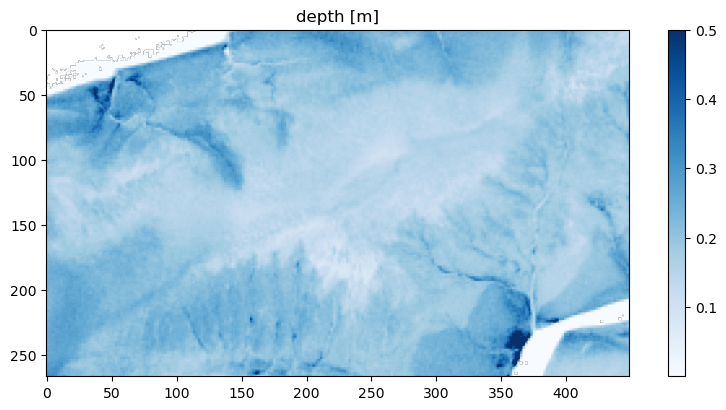

In [16]:
plt.figure(figsize=(10,4.5))
plt.imshow(result[0], cmap='Blues', vmax=0.5)
plt.title('depth [m]')
plt.colorbar()
plt.show()

## Forward simulations on inversion results